In [2]:
# load relevant packages
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import to_rgb
from matplotlib.patches import Patch
import datetime as dt

I start by reading in the MP and posts dataframes. I count the number of MPs per party and the number of MPs in each party that have an actual Bluesky account.

In [3]:
# read in all the retrieved posts
posts_df = pd.read_csv("../01_data/clean_data/all_posts_cleaned.csv")

# create proper date columns
posts_df["date"] = pd.to_datetime(posts_df["date"], utc=True, format="mixed", errors="raise")
posts_df["year"] = posts_df["date"].dt.isocalendar().year
posts_df["week"] = posts_df["date"].dt.isocalendar().week
posts_df["simple_date"] = posts_df["date"].dt.date
posts_df['year_week'] = posts_df['year'].astype(str) + '-W' + posts_df['week'].astype(str).str.zfill(2)

# read in the MP datasets
bt_21_df = pd.read_csv("../01_data/clean_data/bundestag_21_clean.csv")
bt_25_df = pd.read_csv("../01_data/clean_data/bundestag_25_clean.csv")

# reduce to only those mps having a bsky account
bt_21_bsky_df = bt_21_df[~bt_21_df["clean_handle"].isna()]
bt_25_bsky_df = bt_25_df[~bt_25_df["clean_handle"].isna()]

# count the number of mps per party
party_shares_21 = bt_21_df.groupby("faction").size()
party_shares_25 = bt_25_df.groupby("faction").size()

# count the number of mps per party which have a bsky account
party_shares_bsky_21 = bt_21_bsky_df.groupby("faction").size()
party_shares_bsky_25 = bt_25_bsky_df.groupby("faction").size()

Here, I plot these counts of total number of MPs per party and the number of MPs with a Bluesky account as a barplot for each of the two parliaments. I assign each party their typical color and visualize the number of MPs with an account with a lighter color that I create by applying a custom helper function.

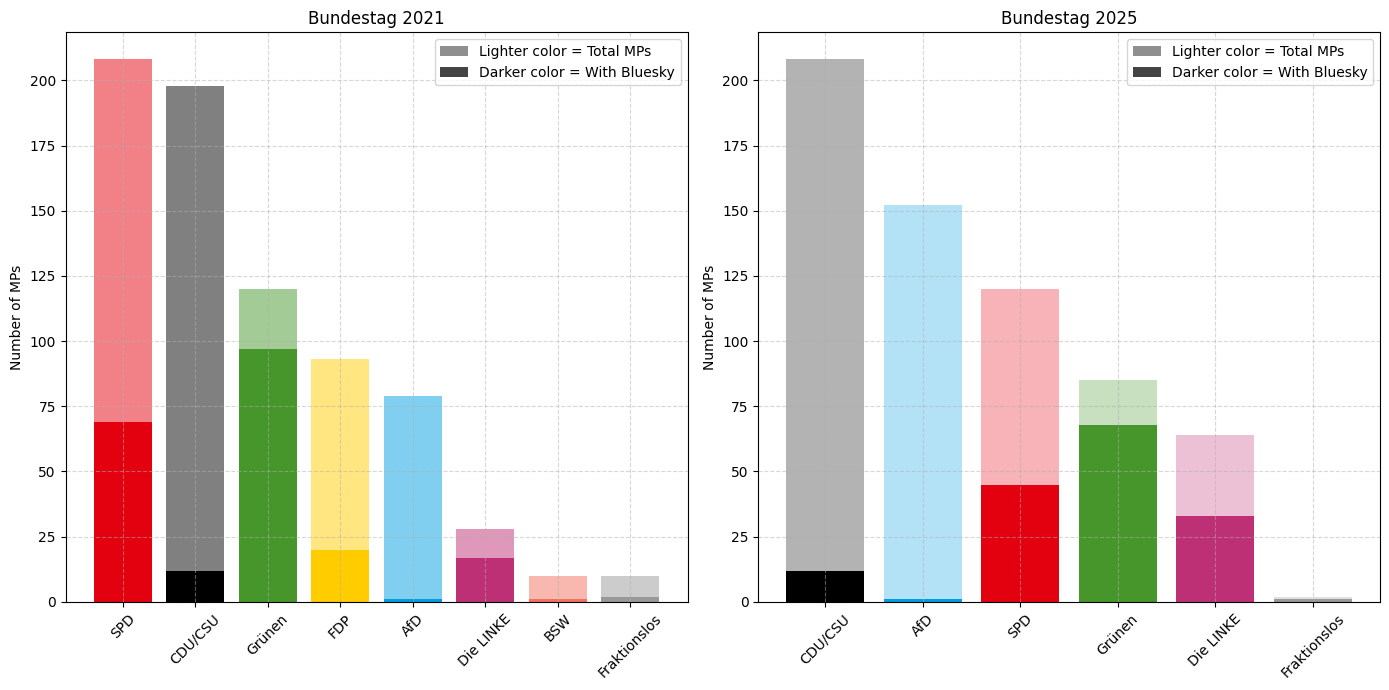

In [17]:
# define party color map
party_colors = {
    'CDU/CSU': '#000000',
    'SPD': '#E3000F',
    'Grünen': '#46962B',
    'FDP': '#FFCC00',
    'AfD': '#009EE0',
    'Die LINKE': '#BE3075',
    'BSW': '#f0715f',
    'Fraktionslos': '#999999',
}

# helper function to lighten a color
def lighten(color, factor=0.5):
    rgb = to_rgb(color)
    return [(1 - factor) * c + factor for c in rgb]

# create legend elements
legend_elements = [
    Patch(facecolor=lighten("#444444", 0.4), label="Lighter color = Total MPs"),
    Patch(facecolor="#444444", label="Darker color = With Bluesky")
]

# ensure that all parties appear in the plots (for both total and bsky count)
all_factions_21 = party_shares_21.index.union(party_shares_bsky_21.index)
total_mps_21 = party_shares_21.reindex(all_factions_21, fill_value=0)
bsky_mps_21 = party_shares_bsky_21.reindex(all_factions_21, fill_value=0)
sorted_indices_21 = total_mps_21.sort_values(ascending=False).index

all_factions_25 = party_shares_25.index.union(party_shares_bsky_25.index)
total_mps_25 = party_shares_25.reindex(all_factions_25, fill_value=0)
bsky_mps_25 = party_shares_bsky_25.reindex(all_factions_25, fill_value=0)
sorted_indices_25 = total_mps_25.sort_values(ascending=False).index

# plot in two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# plot the total number of MPs and the number with a bsky account as a barplot, do this for both parliaments
for party in sorted_indices_21:
    color = party_colors[party]
    axes[0].bar(party, total_mps_21[party], color = lighten(color))
    axes[0].bar(party, bsky_mps_21[party], color = color)
axes[0].set_ylabel("Number of MPs")
axes[0].set_title("Bundestag 2021")
for party in sorted_indices_25:
    color = party_colors[party]
    axes[1].bar(party, total_mps_25[party], color = lighten(color, factor=.7))
    axes[1].bar(party, bsky_mps_25[party], color = color)
axes[1].set_ylabel("Number of MPs")
axes[1].set_title("Bundestag 2025")

# add legends and rotate party names
axes[0].legend(handles=legend_elements, loc='upper right', ncol=1)
axes[1].legend(handles=legend_elements, loc='upper right', ncol=1)
axes[0].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="x", rotation=45)

# add a grid
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

# save and show the plot
plt.savefig("../02_figures_tables/prop_accounts_pp.png", dpi=300)
plt.show()

Next, I calculate the number of MPs per party who have actually posted on Bluesky and compare this with the number of MPs that have generally an account.

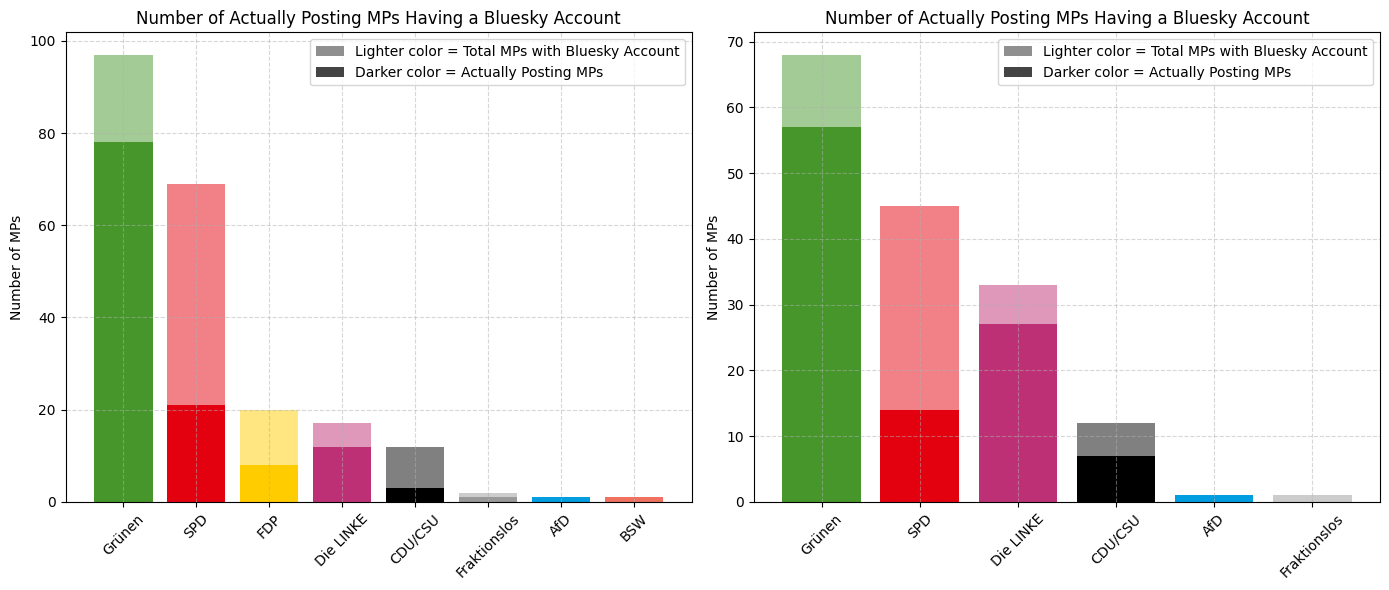

In [18]:
# cut the posts df in two according to legislature
posts_21_df = posts_df[posts_df["simple_date"] <= dt.date(2025, 3, 24)]
posts_25_df = posts_df[posts_df["simple_date"] >= dt.date(2025, 3, 25)]

# count the number of posting mp per party
posting_mps_21 = posts_21_df.drop_duplicates(subset=["clean_handle"]).groupby("faction").size()
posting_mps_25 = posts_25_df.drop_duplicates(subset=["clean_handle"]).groupby("faction").size()

# create legend elements
legend_elements = [
    Patch(facecolor=lighten("#444444", 0.4), label="Lighter color = Total MPs with Bluesky Account"),
    Patch(facecolor="#444444", label="Darker color = Actually Posting MPs")
]

# ensure that all parties appear in the plots (for both total and bsky count)
all_factions_bsky_21 = party_shares_bsky_21.index.union(posting_mps_21.index)
party_shares_bsky_21 = party_shares_bsky_21.reindex(all_factions_bsky_21, fill_value=0)
posting_mps_21 = posting_mps_21.reindex(all_factions_bsky_21, fill_value=0)
sorted_indices_21 = party_shares_bsky_21.sort_values(ascending=False).index

all_factions_bsky_25 = party_shares_bsky_25.index.union(posting_mps_25.index)
party_shares_bsky_25 = party_shares_bsky_25.reindex(all_factions_bsky_25, fill_value=0)
posting_mps_25 = posting_mps_25.reindex(all_factions_bsky_25, fill_value=0)
sorted_indices_25 = party_shares_bsky_25.sort_values(ascending=False).index

# plot in two subplots
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# plot the total number of MPs with an account and the number of MPs who actually post for both parliaments
for party in sorted_indices_21:
    color = party_colors[party]
    axes[0].bar(party, party_shares_bsky_21[party], color = lighten(color))
    axes[0].bar(party, posting_mps_21[party], color = color)
axes[0].set_ylabel("Number of MPs")
axes[0].set_title("Number of Actually Posting MPs Having a Bluesky Account")
for party in sorted_indices_25:
    color = party_colors[party]
    axes[1].bar(party, party_shares_bsky_25[party], color = lighten(color))
    axes[1].bar(party, posting_mps_25[party], color = color)
axes[1].set_ylabel("Number of MPs")
axes[1].set_title("Number of Actually Posting MPs Having a Bluesky Account")

# add legends and rotate party names
axes[0].legend(handles=legend_elements, loc='upper right', ncol=1)
axes[1].legend(handles=legend_elements, loc='upper right', ncol=1)
axes[0].tick_params(axis="x", rotation=45)
axes[1].tick_params(axis="x", rotation=45)

# add a grid
axes[0].grid(True, linestyle="--", alpha=0.5)
axes[1].grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

One can clearly see that many MPs have empty accounts in which they never actually posted or only reposted other messages.